In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()
df.shape
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
df = pd.get_dummies(df)
df.head()

,math score,reading score,writing score,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,72,72,74,True,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,True
1,69,90,88,True,False,False,False,True,False,False,False,False,False,False,True,False,False,True,True,False
2,90,95,93,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True
3,47,57,44,False,True,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True
4,76,78,75,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True


In [ ]:
X = df.drop("math score", axis=1)

y = df["math score"]

In [ ]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled,
                        columns=X.columns)
X_scaled.head()

,reading score,writing score,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,0.662651,0.711111,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.879518,0.866667,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,0.939759,0.922222,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.481928,0.377778,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.734940,0.722222,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
processed_data = X_scaled.copy()

processed_data["math score"] = y

processed_data.head()

,reading score,writing score,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none,math score
0,0.662651,0.711111,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,72
1,0.879518,0.866667,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,69
2,0.939759,0.922222,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,90
3,0.481928,0.377778,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,47
4,0.734940,0.722222,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,76


In [ ]:
num_clients = 5
client_size = len(processed_data) // num_clients
clients = []
for i in range(num_clients):

    start = i * client_size

    if i == num_clients - 1:
        end = len(processed_data)
    else:
        end = (i + 1) * client_size

    client_data = processed_data.iloc[start:end]

    clients.append(client_data)

In [ ]:
for i, client in enumerate(clients):

    print("Client", i+1)

    print(client.shape)

    print(client.head())

    print("-"*40)

Client 1
(200, 20)
   reading score  writing score  gender_female  gender_male  \
0       0.662651       0.711111            1.0          0.0   
1       0.879518       0.866667            1.0          0.0   
2       0.939759       0.922222            1.0          0.0   
3       0.481928       0.377778            0.0          1.0   
4       0.734940       0.722222            0.0          1.0   

   race/ethnicity_group A  race/ethnicity_group B  race/ethnicity_group C  \
0                     0.0                     1.0                     0.0   
1                     0.0                     0.0                     1.0   
2                     0.0                     1.0                     0.0   
3                     1.0                     0.0                     0.0   
4                     0.0                     0.0                     1.0   

   race/ethnicity_group D  race/ethnicity_group E  \
0                     0.0                     0.0   
1                     0.0        

In [ ]:
for i, client in enumerate(clients):

    client.to_csv(f"client_{i+1}.csv",
                  index=False)

In [ ]:
for i in range(len(clients)):

    print("Client", i+1)

    print(clients[i].shape)

Client 1
(200, 20)
Client 2
(200, 20)
Client 3
(200, 20)
Client 4
(200, 20)
Client 5
(200, 20)


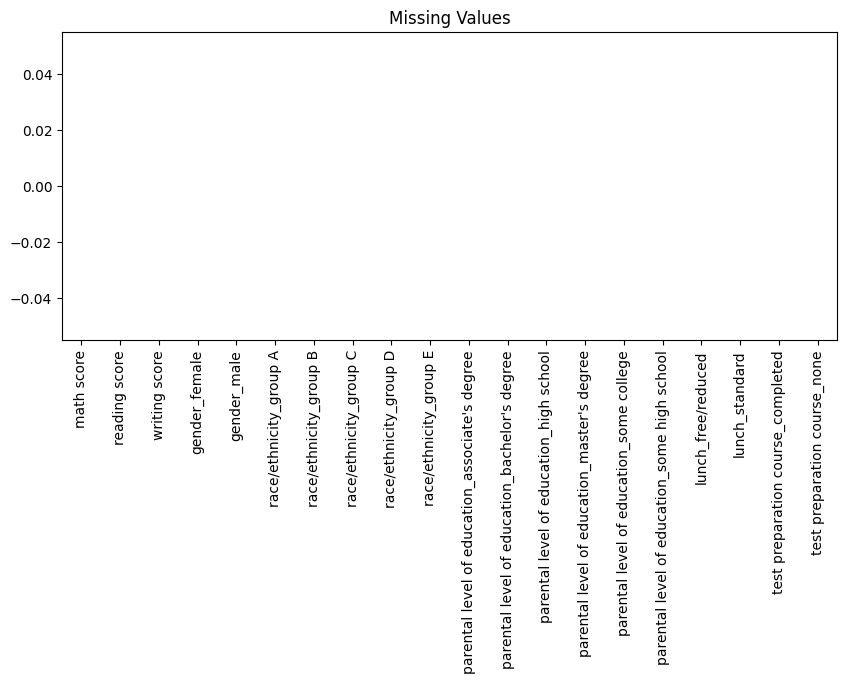

In [ ]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

plt.figure(figsize=(10,4))
missing.plot(kind='bar')
plt.title("Missing Values")
plt.show()

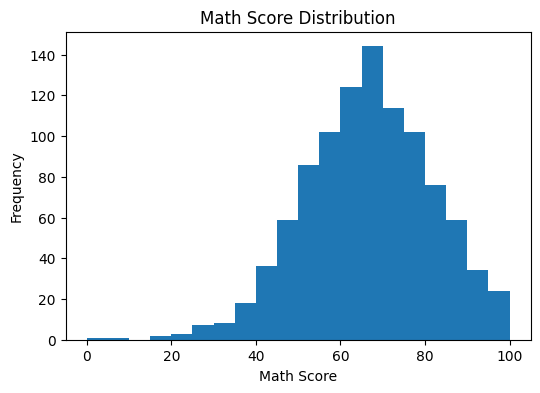

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(y, bins=20)

plt.title("Math Score Distribution")

plt.xlabel("Math Score")

plt.ylabel("Frequency")

plt.show()

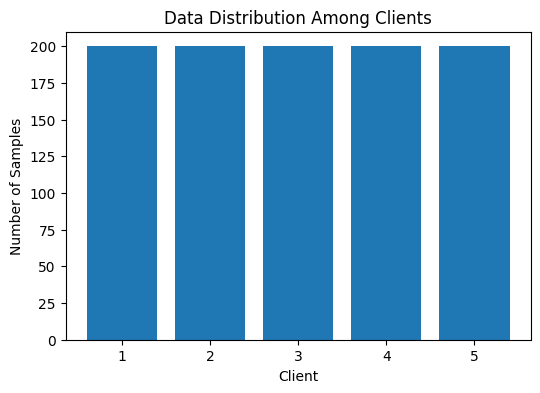

In [ ]:
sizes = [len(c) for c in clients]

plt.figure(figsize=(6,4))

plt.bar(range(1,6), sizes)

plt.xlabel("Client")

plt.ylabel("Number of Samples")

plt.title("Data Distribution Among Clients")

plt.show()